In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import deepxde as dde
import os

In [76]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
OUTPUT_DIR = "model_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [65]:
df = pd.read_csv("graph_outputs/seir_counts.csv")
 
N = df[["S", "E", "I", "R"]].iloc[0].sum()   # total population (constant)
 
# Combine S+E → "susceptible/undetected" observable; keep I and R
df["SE"] = df["S"] + df["E"]

In [66]:
mid = len(df) // 2
first_half  = df.iloc[:mid]
second_half = df.iloc[mid:].sort_values("t").reset_index(drop=True)

train_df = first_half.sample(n=50, random_state=SEED).sort_values("t").reset_index(drop=True)

t_train  = train_df["t"].values.astype(float)
SE_train = train_df["SE"].values.astype(float)
I_train  = train_df["I"].values.astype(float)
R_train  = train_df["R"].values.astype(float)

t_test  = second_half["t"].values.astype(float)
SE_test = second_half["SE"].values.astype(float)
I_test  = second_half["I"].values.astype(float)
R_test  = second_half["R"].values.astype(float)

# Stack observations: columns = [SE, I, R]
y_train = np.stack([SE_train, I_train, R_train], axis=1)
y_test  = np.stack([SE_test,  I_test,  R_test],  axis=1)
 
t_min, t_max = df["t"].min(), df["t"].max()
t_train_norm = (t_train - t_min) / (t_max - t_min)
t_test_norm  = (t_test  - t_min) / (t_max - t_min)

print(f"Train size: {len(t_train)}  |  Test size: {len(t_test)}")
print(f"Population N = {N}")

Train size: 50  |  Test size: 124
Population N = 10000


In [67]:
def seir_ode(t, y, beta, sigma, gamma):
    S, E, I, R = y
    dS = -beta * S * I / N
    dE =  beta * S * I / N - sigma * E
    dI =  sigma * E - gamma * I
    dR =  gamma * I
    return [dS, dE, dI, dR]
 
def seir_predict(params, t_eval):
    beta, sigma, gamma = params
    S0 = float(df["S"].iloc[0])
    E0 = float(df["E"].iloc[0])
    I0 = float(df["I"].iloc[0])
    R0 = float(df["R"].iloc[0])
    
    # always start from t=0, integrate through the full range
    t_start = df["t"].min()
    sol = solve_ivp(
        seir_ode,
        t_span=(t_start, t_eval.max()),
        y0=[S0, E0, I0, R0],
        t_eval=np.concatenate([[t_start], t_eval]) if t_eval.min() > t_start else t_eval,
        args=(beta, sigma, gamma),
        method="RK45",
        dense_output=False,
    )
    # extract only the requested t_eval points
    mask = np.isin(np.round(sol.t, 8), np.round(t_eval, 8))
    S, E, I, R = sol.y[:, mask]
    return np.stack([S + E, I, R], axis=1)
 
def seir_loss(log_params):
    params = np.exp(log_params)              # keep params positive
    pred   = seir_predict(params, t_train)
    if pred.shape[0] != len(t_train):
        return 1e10
    resid  = (pred - y_train) / (y_train.max(axis=0) + 1e-8)
    return np.mean(resid**2)
 
print("\n[1/3] Fitting mechanistic SEIR …")
x0 = np.log([0.3, 0.2, 0.1])
res = minimize(seir_loss, x0, method="Nelder-Mead",
               options={"maxiter": 10000, "xatol": 1e-6, "fatol": 1e-6})
seir_params = np.exp(res.x)
print(f"  beta={seir_params[0]:.4f}  sigma={seir_params[1]:.4f}  gamma={seir_params[2]:.4f}")
 
seir_pred_test  = seir_predict(seir_params, t_test)
seir_pred_train = seir_predict(seir_params, t_train)


[1/3] Fitting mechanistic SEIR …
  beta=0.1849  sigma=0.2225  gamma=0.0501


In [68]:
class SimpleNN(nn.Module):
    def __init__(self, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 3))   # outputs: SE, I, R
        self.net = nn.Sequential(*layers)
 
    def forward(self, t):
        return self.net(t)
 
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train)
 
t_tr  = torch.tensor(t_train_norm[:, None], dtype=torch.float32)
y_tr  = torch.tensor(y_train_scaled,        dtype=torch.float32)
t_te  = torch.tensor(t_test_norm[:, None],  dtype=torch.float32)
 
nn_model   = SimpleNN(hidden=64, depth=4)
optimizer  = torch.optim.Adam(nn_model.parameters(), lr=1e-3)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)
loss_fn    = nn.MSELoss()
 
print("\n[2/3] Training neural network …")
NN_EPOCHS = 10000
for epoch in range(1, NN_EPOCHS + 1):
    nn_model.train()
    optimizer.zero_grad()
    pred = nn_model(t_tr)
    loss = loss_fn(pred, y_tr)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 2000 == 0:
        print(f"  epoch {epoch:5d}  loss={loss.item():.6f}")
 
nn_model.eval()
with torch.no_grad():
    nn_pred_test_scaled  = nn_model(t_te).numpy()
    nn_pred_train_scaled = nn_model(t_tr).numpy()
 
nn_pred_test  = scaler.inverse_transform(nn_pred_test_scaled)
nn_pred_train = scaler.inverse_transform(nn_pred_train_scaled)


[2/3] Training neural network …
  epoch  2000  loss=0.000007
  epoch  4000  loss=0.000007
  epoch  6000  loss=0.000007
  epoch  8000  loss=0.000007
  epoch 10000  loss=0.000007


In [69]:
print("\n[3/3] Training PINN (DeepXDE) …")
 
# Trainable SEIR parameters (log-space for positivity)
log_beta  = dde.Variable(np.log(0.3))
log_sigma = dde.Variable(np.log(0.2))
log_gamma = dde.Variable(np.log(0.1))
 
def pinn_ode(t, y):
    """ODE residuals for the PINN. y = [S, E, I, R]."""
    beta  = torch.exp(log_beta)
    sigma = torch.exp(log_sigma)
    gamma = torch.exp(log_gamma)
 
    S, E, I, R_ = y[:, 0:1], y[:, 1:2], y[:, 2:3], y[:, 3:4]
 
    dS  = dde.grad.jacobian(y, t, i=0)
    dE  = dde.grad.jacobian(y, t, i=1)
    dI  = dde.grad.jacobian(y, t, i=2)
    dR  = dde.grad.jacobian(y, t, i=3)
 
    res_S = dS + beta * S * I / N
    res_E = dE - beta * S * I / N + sigma * E
    res_I = dI - sigma * E + gamma * I
    res_R = dR - gamma * I
 
    return [res_S, res_E, res_I, res_R]
 
# Geometry: 1-D time domain
geom = dde.geometry.TimeDomain(t_min, t_max)


[3/3] Training PINN (DeepXDE) …


In [70]:
obs_I = dde.PointSetBC(
    t_train[:, None],
    I_train[:, None],
    component=2,
)
obs_R = dde.PointSetBC(
    t_train[:, None],
    R_train[:, None],
    component=3,
)
 
# Initial conditions from first data row
ic_S = dde.IC(geom, lambda _: df["S"].iloc[0], lambda _, on_initial: on_initial, component=0)
ic_E = dde.IC(geom, lambda _: df["E"].iloc[0], lambda _, on_initial: on_initial, component=1)
ic_I = dde.IC(geom, lambda _: df["I"].iloc[0], lambda _, on_initial: on_initial, component=2)
ic_R = dde.IC(geom, lambda _: df["R"].iloc[0], lambda _, on_initial: on_initial, component=3)
 
data = dde.data.TimePDE(
    geom,
    pinn_ode,
    [ic_S, ic_E, ic_I, ic_R, obs_I, obs_R],
    num_domain=200,
    num_boundary=2,
    anchors=t_train[:, None],
)
 
# Network: maps t → [S, E, I, R]
net = dde.nn.FNN(
    layer_sizes=[1] + [64] * 4 + [4],
    activation="tanh",
    kernel_initializer="Glorot normal",
)
 
# Scale outputs to [0, N] range
net.apply_output_transform(lambda _, y: y * N)
 
pinn = dde.Model(data, net)
pinn.compile(
    "adam",
    lr=1e-3,
    external_trainable_variables=[log_beta, log_sigma, log_gamma],
)
 
checker = dde.callbacks.VariableValue(
    [log_beta, log_sigma, log_gamma],
    period=2000,
    filename="pinn_params.dat",
)
 
losshistory, train_state = pinn.train(
    iterations=25000,
    callbacks=[checker],
    display_every=2000,
)
 
# Fine-tune with L-BFGS
pinn.compile("L-BFGS", external_trainable_variables=[log_beta, log_sigma, log_gamma])
losshistory, train_state = pinn.train()
 
pinn_params = {
    "beta":  float(torch.exp(log_beta).detach()),
    "sigma": float(torch.exp(log_sigma).detach()),
    "gamma": float(torch.exp(log_gamma).detach()),
}
print(f"  PINN learned: {pinn_params}")
 
pinn_pred_test_full  = pinn.predict(t_test[:, None])   # shape (n, 4): S, E, I, R
pinn_pred_train_full = pinn.predict(t_train[:, None])
 
# Reconstruct observable SE = S + E
pinn_pred_test  = np.stack([
    pinn_pred_test_full[:, 0] + pinn_pred_test_full[:, 1],
    pinn_pred_test_full[:, 2],
    pinn_pred_test_full[:, 3],
], axis=1)
 
pinn_pred_train = np.stack([
    pinn_pred_train_full[:, 0] + pinn_pred_train_full[:, 1],
    pinn_pred_train_full[:, 2],
    pinn_pred_train_full[:, 3],
], axis=1)

Compiling model...
'compile' took 0.000532 s



Training model...

Step      Train loss                                                                                              Test loss                                                                                               Test metric
0         [2.20e+04, 4.10e+05, 3.66e+05, 9.77e+04, 9.98e+07, 0.00e+00, 1.00e+02, 0.00e+00, 5.02e+06, 4.68e+07]    [2.20e+04, 4.10e+05, 3.66e+05, 9.77e+04, 9.98e+07, 0.00e+00, 1.00e+02, 0.00e+00, 5.02e+06, 4.68e+07]    []  
2000      [1.97e+03, 4.06e+02, 4.01e+02, 1.07e+03, 4.21e-02, 1.98e-03, 2.21e-05, 1.19e-02, 3.41e+04, 5.21e+03]    [1.97e+03, 4.06e+02, 4.01e+02, 1.07e+03, 4.21e-02, 1.98e-03, 2.21e-05, 1.19e-02, 3.41e+04, 5.21e+03]    []  
4000      [4.12e+02, 1.38e+02, 1.67e+02, 3.27e+02, 1.61e-04, 8.13e-05, 1.16e-03, 5.38e-04, 6.97e+02, 1.90e+02]    [4.12e+02, 1.38e+02, 1.67e+02, 3.27e+02, 1.61e-04, 8.13e-05, 1.16e-03, 5.38e-04, 6.97e+02, 1.90e+02]    []  
6000      [1.96e+02, 5.21e+01, 1.05e+02, 9.08e+01, 1.47e-01, 2.24e-01, 3.01e+00, 1

In [71]:
def metrics(pred, true, name):
    rmse = np.sqrt(mean_squared_error(true, pred))
    rel  = np.mean(np.abs(pred - true) / (np.abs(true) + 1e-8))
    print(f"  {name:<20s}  RMSE={rmse:10.2f}  RelMAE={rel:.4f}")
    return rmse, rel
 
print("\n── Test-set metrics (SE, I, R combined) ──")
seir_rmse, seir_rel = metrics(seir_pred_test, y_test, "Mechanistic SEIR")
nn_rmse,   nn_rel   = metrics(nn_pred_test,   y_test, "Neural Network")
pinn_rmse, pinn_rel = metrics(pinn_pred_test,  y_test, "PINN")
 
# Per-compartment RMSE
print("\n── Per-compartment RMSE on test set ──")
labels = ["SE (S+E)", "I", "R"]
for i, lbl in enumerate(labels):
    print(f"  {lbl:<12s}"
          f"  SEIR={np.sqrt(mean_squared_error(y_test[:, i], seir_pred_test[:, i])):8.2f}"
          f"  NN={np.sqrt(mean_squared_error(y_test[:, i], nn_pred_test[:, i])):8.2f}"
          f"  PINN={np.sqrt(mean_squared_error(y_test[:, i], pinn_pred_test[:, i])):8.2f}")


── Test-set metrics (SE, I, R combined) ──
  Mechanistic SEIR      RMSE=    261.38  RelMAE=2237967.4835
  Neural Network        RMSE=   1412.84  RelMAE=68608455.1932
  PINN                  RMSE=    225.87  RelMAE=7064492.4856

── Per-compartment RMSE on test set ──
  SE (S+E)      SEIR=  317.19  NN= 1654.94  PINN=  305.74
  I             SEIR=   40.97  NN=  284.53  PINN=   56.50
  R             SEIR=  320.43  NN= 1780.04  PINN=  237.45



Plot saved → seir_model_comparison.png


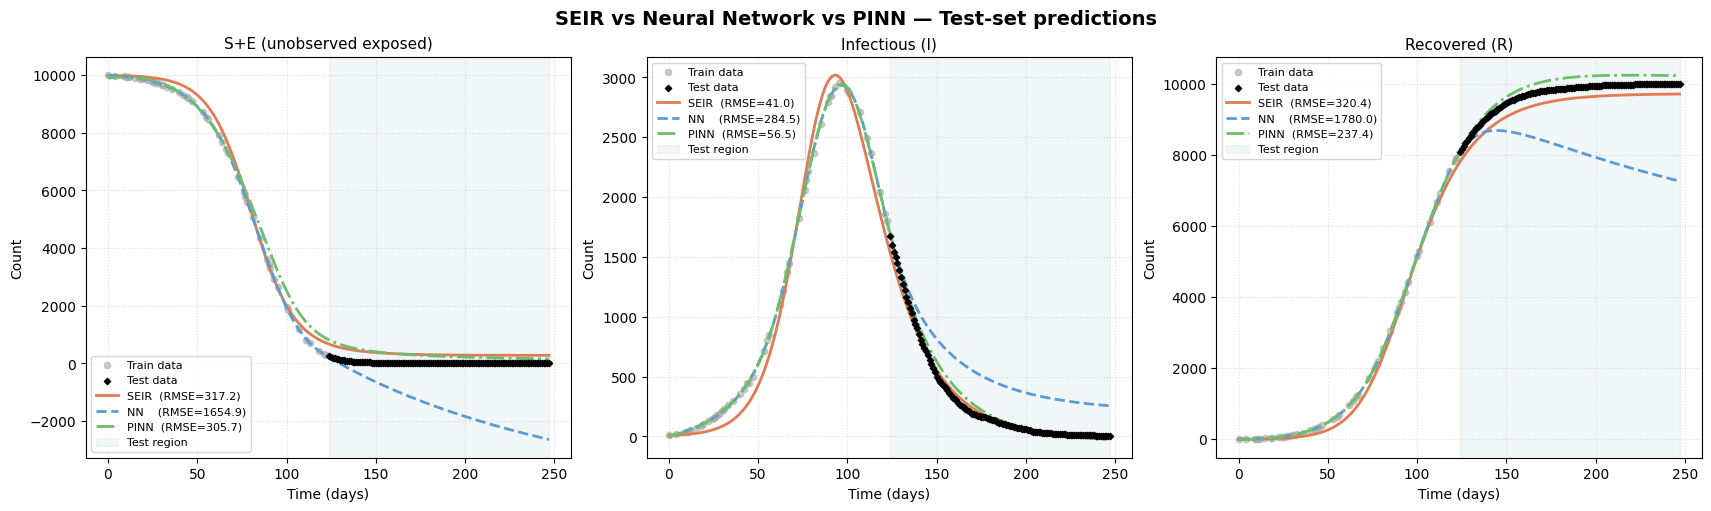

In [77]:
# Dense prediction grid for smooth curves
t_dense = np.linspace(t_min, t_max, 400)
seir_dense = seir_predict(seir_params, t_dense)
 
t_dense_norm = (t_dense - t_min) / (t_max - t_min)
with torch.no_grad():
    nn_dense_scaled = nn_model(
        torch.tensor(t_dense_norm[:, None], dtype=torch.float32)
    ).numpy()
nn_dense = scaler.inverse_transform(nn_dense_scaled)
 
pinn_dense_full = pinn.predict(t_dense[:, None])
pinn_dense = np.stack([
    pinn_dense_full[:, 0] + pinn_dense_full[:, 1],
    pinn_dense_full[:, 2],
    pinn_dense_full[:, 3],
], axis=1)
 
compartments = ["S+E (unobserved exposed)", "Infectious (I)", "Recovered (R)"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
fig.suptitle("SEIR vs Neural Network vs PINN — Test-set predictions", fontsize=14, fontweight="bold")
 
colors = {"SEIR": "#e07b54", "NN": "#5b9bd5", "PINN": "#6bbf6b"}
 
for ax, comp_idx, comp_name in zip(axes, range(3), compartments):
    # Training data (light)
    ax.scatter(t_train, y_train[:, comp_idx],
               s=20, color="#aaaaaa", alpha=0.6, label="Train data", zorder=2)
    # Test data (bold)
    ax.scatter(t_test, y_test[:, comp_idx],
               s=10, color="black", marker="D", label="Test data", zorder=3)
 
    # Model curves (dense)
    ax.plot(t_dense, seir_dense[:, comp_idx],
            color=colors["SEIR"], lw=2, label=f"SEIR  (RMSE={np.sqrt(mean_squared_error(y_test[:, comp_idx], seir_pred_test[:, comp_idx])):.1f})")
    ax.plot(t_dense, nn_dense[:, comp_idx],
            color=colors["NN"],   lw=2, linestyle="--",
            label=f"NN    (RMSE={np.sqrt(mean_squared_error(y_test[:, comp_idx], nn_pred_test[:, comp_idx])):.1f})")
    ax.plot(t_dense, pinn_dense[:, comp_idx],
            color=colors["PINN"], lw=2, linestyle="-.",
            label=f"PINN  (RMSE={np.sqrt(mean_squared_error(y_test[:, comp_idx], pinn_pred_test[:, comp_idx])):.1f})")
 
    # Shade test region
    ax.axvspan(t_test.min(), t_test.max(), alpha=0.07, color="steelblue", label="Test region")
 
    ax.set_title(comp_name, fontsize=11)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, linestyle=":", alpha=0.4)
 
plt.savefig(f"{OUTPUT_DIR}/seir_model_comparison.png", dpi=150, bbox_inches="tight")
print("\nPlot saved → seir_model_comparison.png")
plt.show()

Plot saved → seir_E_compartment.png


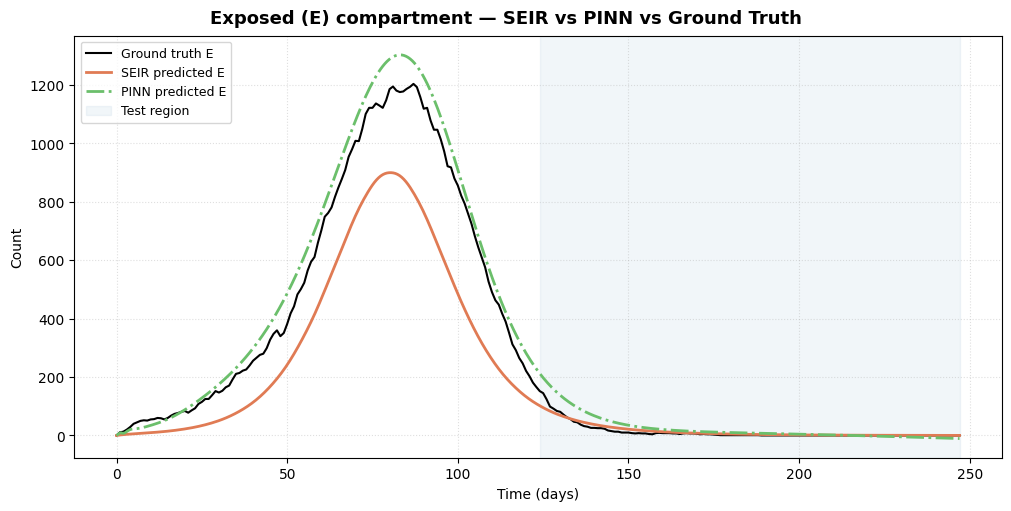

In [78]:
# Ground truth E from full csv
t_gt = df["t"].values.astype(float)
E_gt = df["E"].values.astype(float)

# Redefine a version of seir_predict that returns all 4 compartments
def seir_predict_raw(params, t_eval):
    beta, sigma, gamma = params
    S0 = float(df["S"].iloc[0])
    E0 = float(df["E"].iloc[0])
    I0 = float(df["I"].iloc[0])
    R0 = float(df["R"].iloc[0])
    t_start = df["t"].min()
    sol = solve_ivp(
        seir_ode,
        t_span=(t_start, t_eval.max()),
        y0=[S0, E0, I0, R0],
        t_eval=np.concatenate([[t_start], t_eval]) if t_eval.min() > t_start else t_eval,
        args=(beta, sigma, gamma),
        method="RK45",
    )
    mask = np.isin(np.round(sol.t, 8), np.round(t_eval, 8))
    return sol.y[:, mask]  # shape (4, n): S, E, I, R

seir_raw   = seir_predict_raw(seir_params, t_dense)   # (4, 400)
E_seir     = seir_raw[1]                               # row 1 = E

E_pinn     = pinn_dense_full[:, 1]                     # column 1 = E from PINN output

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
fig.suptitle("Exposed (E) compartment — SEIR vs PINN vs Ground Truth", fontsize=13, fontweight="bold")

ax.plot(t_gt,    E_gt,    color="black",          lw=1.5, label="Ground truth E")
ax.plot(t_dense, E_seir,  color=colors["SEIR"],   lw=2,   label="SEIR predicted E")
ax.plot(t_dense, E_pinn,  color=colors["PINN"],   lw=2,   linestyle="-.", label="PINN predicted E")

ax.axvspan(t_test.min(), t_test.max(), alpha=0.07, color="steelblue", label="Test region")

ax.set_xlabel("Time (days)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.4)

plt.savefig(f"{OUTPUT_DIR}/seir_E_compartment.png", dpi=150, bbox_inches="tight")
print("Plot saved → seir_E_compartment.png")
plt.show()